In [0]:
   %pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
display(spark.table("clean_dataset").limit(5))

airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [0]:
df = spark.table("clean_dataset")
print("Rows:- ",df.count())
df.printSchema()

Rows:-  300153
root
 |-- airline: string (nullable = true)
 |-- flight: string (nullable = true)
 |-- source_city: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stops: string (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- destination_city: string (nullable = true)
 |-- class: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- days_left: long (nullable = true)
 |-- price: long (nullable = true)



In [0]:
display(df.summary("count"))

summary,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153,300153,300153


In [0]:
spark.table("clean_dataset").write.mode("overwrite").saveAsTable("flights_bronze")

In [0]:
display(spark.table("clean_dataset").select("duration", "days_left", "price").summary())

summary,duration,days_left,price
count,300153,300153,300153
mean,12.221020812717917,26.004750910369044,20889.660523133203
stddev,7.191997238119014,13.561003687093566,22697.767366074462
min,0.83,1,1105
25%,6.83,15,4783
50%,11.25,26,7425
75%,16.17,38,42521
max,49.83,49,123071


In [0]:
df = spark.table("clean_dataset")
total = df.count()
unique = df.dropDuplicates().count()
print("Rows:", total, "| Unique rows:", unique, "| Duplicates:", total - unique)

Rows: 300153 | Unique rows: 300153 | Duplicates: 0


In [0]:
flights = (spark.table("clean_dataset")
           .withColumnRenamed("class", "travel_class")
           .drop("flight"))
flights.write.mode("overwrite").saveAsTable("flights_silver")
print("Rows:", flights.count())
flights.printSchema()

Rows: 300153
root
 |-- airline: string (nullable = true)
 |-- source_city: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stops: string (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- destination_city: string (nullable = true)
 |-- travel_class: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- days_left: long (nullable = true)
 |-- price: long (nullable = true)



In [0]:
%sql
SELECT airline, travel_class, COUNT(*) AS flights, ROUND(AVG(price)) AS avg_price
FROM flights_silver
GROUP BY airline, travel_class
ORDER BY travel_class, avg_price DESC

airline,travel_class,flights,avg_price
Vistara,Business,60589,55477.0
Air_India,Business,32898,47131.0
Vistara,Economy,67270,7807.0
Air_India,Economy,47994,7314.0
SpiceJet,Economy,9011,6179.0
GO_FIRST,Economy,23173,5652.0
Indigo,Economy,43120,5324.0
AirAsia,Economy,16098,4091.0


In [0]:
%sql
SELECT travel_class,
       CASE WHEN days_left <= 7  THEN '01-07 days'
            WHEN days_left <= 14 THEN '08-14 days'
            WHEN days_left <= 30 THEN '15-30 days'
            ELSE '31+ days' END AS days_before_departure,
       COUNT(*) AS flights,
       ROUND(AVG(price)) AS avg_price
FROM flights_silver
GROUP BY 1, 2
ORDER BY travel_class, MIN(days_left)

travel_class,days_before_departure,flights,avg_price
Business,01-07 days,10548,56745.0
Business,08-14 days,13772,52693.0
Business,15-30 days,31828,52126.0
Business,31+ days,37339,51649.0
Economy,01-07 days,21565,11634.0
Economy,08-14 days,29033,10048.0
Economy,15-30 days,71746,5588.0
Economy,31+ days,84322,4919.0


Databricks visualization. Run in Databricks to view.

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = spark.table("flights_silver").toPandas()
print(data.shape)

y = data["price"]
X = pd.get_dummies(data.drop(columns=["price"]), dtype=int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

(300153, 10)
Train: (240122, 37) | Test: (60031, 37)


In [0]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

lin = LinearRegression().fit(X_train, y_train)
gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, random_state=42).fit(X_train, y_train)

for name, model in [("Linear regression", lin), ("Gradient boosting", gbm)]:
    pred = model.predict(X_test)
    print(f"{name}: MAE = Rs {mean_absolute_error(y_test, pred):,.0f} | R2 = {r2_score(y_test, pred):.3f}")

Linear regression: MAE = Rs 4,553 | R2 = 0.911
Gradient boosting: MAE = Rs 2,002 | R2 = 0.977


In [0]:
pred = gbm.predict(X_test)
is_business = X_test["travel_class_Business"] == 1

for label, mask in [("Business", is_business), ("Economy", ~is_business)]:
    mae = mean_absolute_error(y_test[mask], pred[mask])
    avg = y_test[mask].mean()
    print(f"{label}: MAE = Rs {mae:,.0f} | average price = Rs {avg:,.0f} | error = {mae/avg:.1%}")

Business: MAE = Rs 3,831 | average price = Rs 52,540 | error = 7.3%
Economy: MAE = Rs 1,174 | average price = Rs 6,559 | error = 17.9%


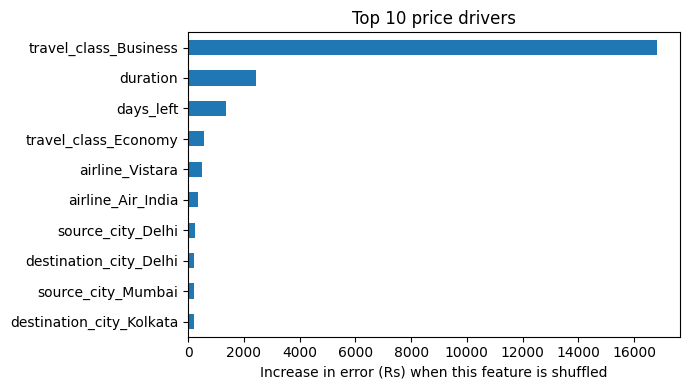

In [0]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

sample = X_test.sample(10000, random_state=42)
imp = permutation_importance(gbm, sample, y_test.loc[sample.index],
                             n_repeats=3, random_state=42,
                             scoring="neg_mean_absolute_error")
top = pd.Series(imp.importances_mean, index=X_test.columns).sort_values().tail(10)

top.plot.barh(figsize=(7, 4))
plt.xlabel("Increase in error (Rs) when this feature is shuffled")
plt.title("Top 10 price drivers")
plt.tight_layout()
plt.show()

In [0]:
import mlflow

def evaluate(model):
    p = model.predict(X_test)
    biz = X_test["travel_class_Business"] == 1
    return {
        "test_mae": mean_absolute_error(y_test, p),
        "test_r2": r2_score(y_test, p),
        "test_mae_business": mean_absolute_error(y_test[biz], p[biz]),
        "test_mae_economy": mean_absolute_error(y_test[~biz], p[~biz]),
    }

runs = [
    ("linear_regression", lin, {"model": "LinearRegression"}),
    ("hist_gradient_boosting", gbm, {"model": "HistGradientBoostingRegressor",
                                     "max_iter": 300, "learning_rate": 0.1}),
]

for run_name, model, params in runs:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({**params, "test_size": 0.2, "n_features": X.shape[1]})
        mlflow.log_metrics(evaluate(model))
        print("Logged:", run_name)

Logged: linear_regression
Logged: hist_gradient_boosting


In [0]:
import xgboost
print(xgboost.__version__)

3.4.1


In [0]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6,
                   random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

scores = evaluate(xgb)
print({k: round(v, 3) for k, v in scores.items()})

with mlflow.start_run(run_name="xgboost"):
    mlflow.log_params({"model": "XGBRegressor", "n_estimators": 300, "learning_rate": 0.1,
                       "max_depth": 6, "test_size": 0.2, "n_features": X.shape[1]})
    mlflow.log_metrics(scores)
    print("Logged: xgboost")

{'test_mae': 1953.946, 'test_r2': 0.977, 'test_mae_business': 3904.284, 'test_mae_economy': 1070.497}
Logged: xgboost
